In [444]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch
import csv
from sbi.analysis import pairplot
import pandas as pd

Dataset 1 Analysis

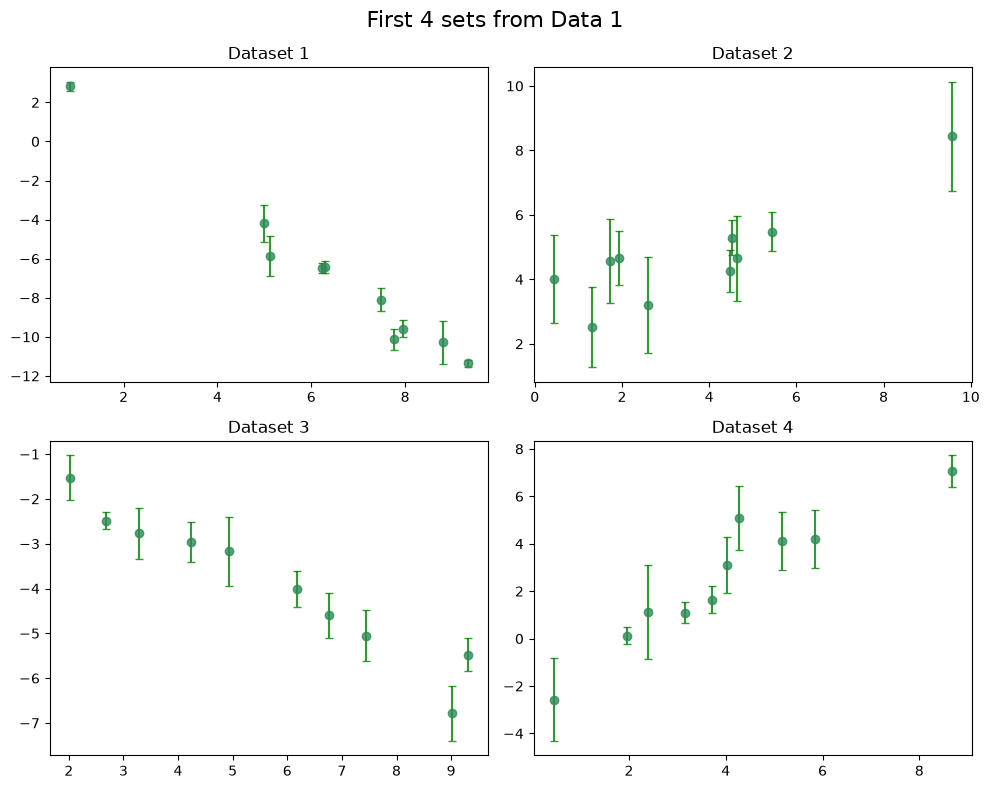

In [481]:
df = pd.read_csv('data1.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='seagreen',
                ecolor='green', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 1', fontsize=16)    
plt.tight_layout()
plt.show()


a = -1.6626831831611895, b = 3.817560809159585
a = 0.5117862550776586, b = 2.831272857074634
a ranges from -2.014 to 2.173
b ranges from -5.394 to 5.513


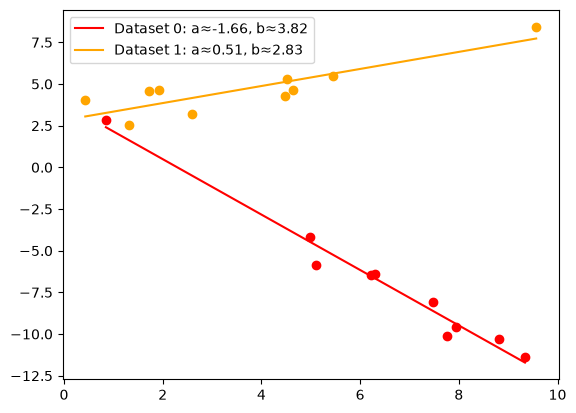

In [482]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

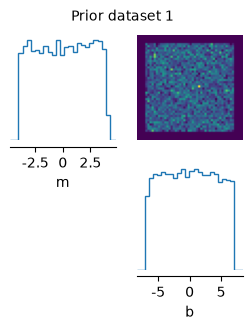

In [484]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_1 = BoxUniform(low=torch.tensor([-4, -7]), 
                      high=torch.tensor([4, 7]))

prior_samples1 = prior_1.sample((10000,))


fig, ax = pairplot(
    prior_samples1,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 1", fontsize = 10 )
plt.show()

In [485]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_1.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_1)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)



 Neural network successfully converged after 224 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -1.717465 0.042523  4.377652 0.274727
       1  0.459582 0.159251  2.957030 0.721320
       2 -0.535040 0.056173 -0.927870 0.299112
       3  1.063093 0.105973 -1.992195 0.437457
       4  1.051399 0.088781  2.714910 0.325242
       5  1.889987 0.111666  1.627789 0.370824
       6 -1.568432 0.028023 -1.217700 0.133835
       7 -1.244410 0.126098  3.250660 0.668958
       8  1.431591 0.120292 -4.036263 0.778048
       9  0.556940 0.094631 -3.318210 0.464663
      10 -1.599679 0.068711  4.638789 0.377701
      11  0.127251 0.066651 -4.377124 0.336136
      12 -0.806345 0.196838  1.937206 0.854620
      13  0.167339 0.169491  3.264437 0.665864
      14  0.043743 0.031540  2.504087 0.147605
      15 -1.038473 0.063329 -4.218291 0.367733
      16  0.125774 0.105316 -3.560605 0.803290
      17  0.346604 0.117809 -0.653643 0.323160
      18 -0.793401 0.079791  2.267134 0.596174
      19 -0.987403 0.165969  0.509258 1.131530
      20  1.6

  0%|          | 0/5000 [00:00<?, ?it/s]

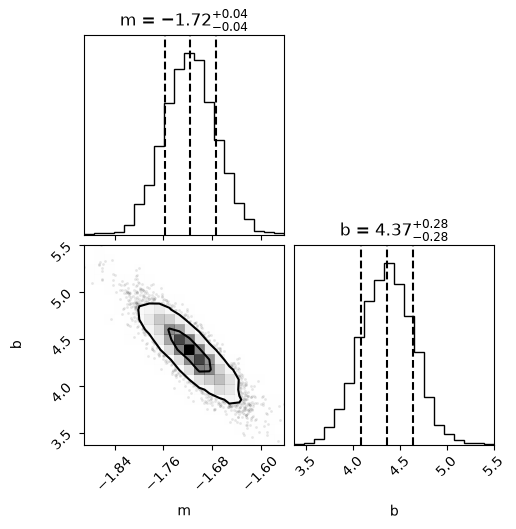

In [487]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)



In [488]:
#How good is this fitting? Doing a sort of posterior predictive check
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)



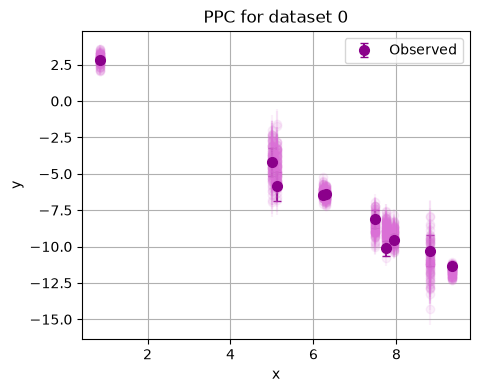

In [489]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id}')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.7868


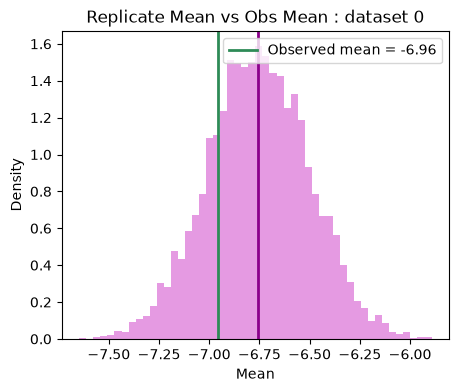

$\Delta$ mean = 0.20


In [490]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id}')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.7414


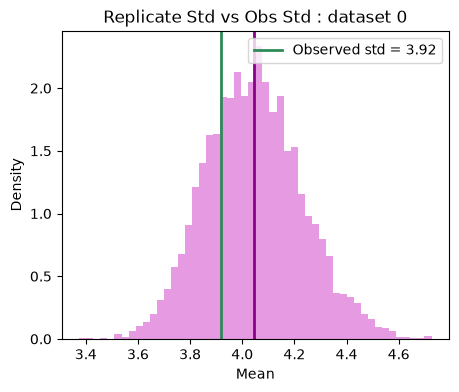

In [491]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id}')
ax.legend()

plt.show()


Dataset 2 Analysis

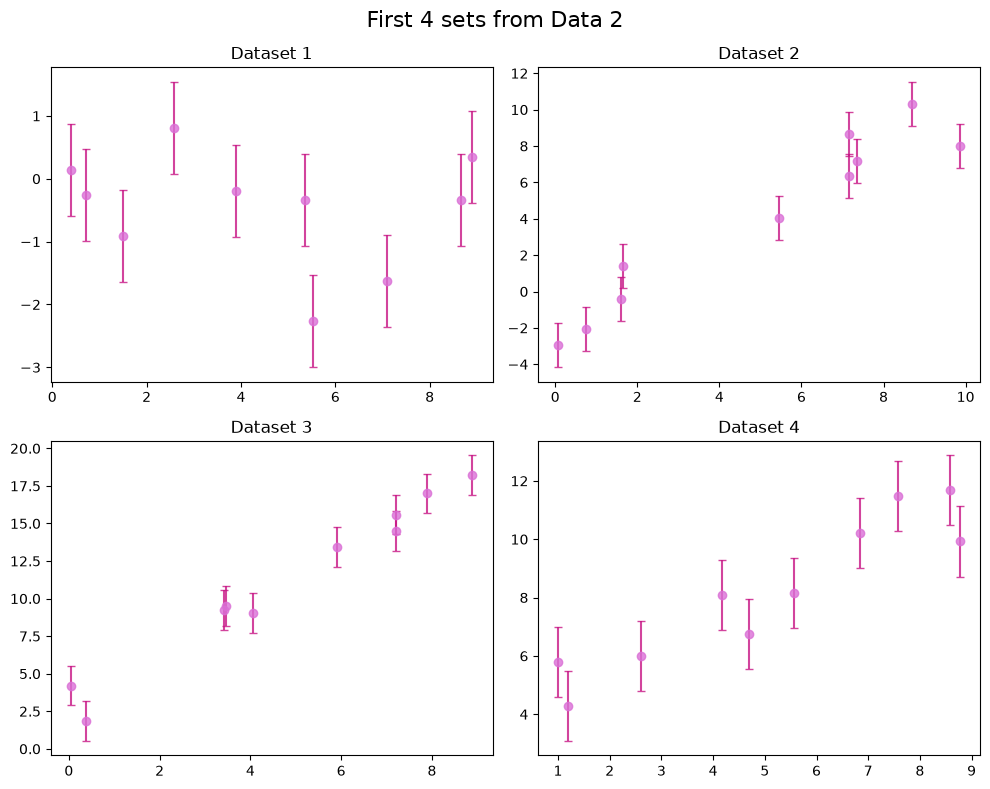

In [454]:
df = pd.read_csv('data2.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='orchid',
                ecolor='mediumvioletred', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 2', fontsize=16)    
plt.tight_layout()
plt.show()

a = -0.05870621822704653, b = -0.20185870388723284
a = 1.2724290503034936, b = -2.272903504453701
a ranges from -2.048 to 2.025
b ranges from -5.716 to 6.051


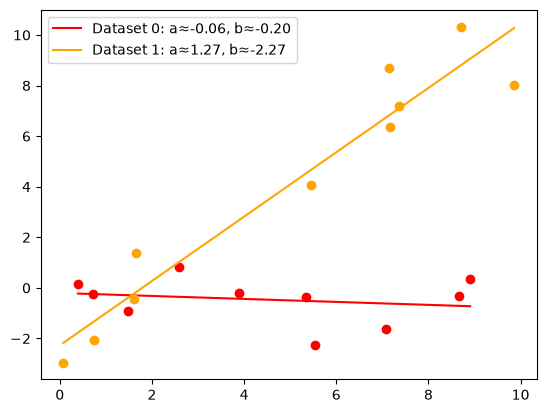

In [455]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

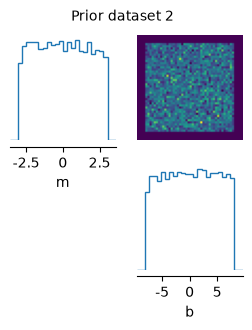

In [456]:
#Creating a prior for the set based on that range

prior_2 = BoxUniform(low=torch.tensor([-3, -8]), 
                      high=torch.tensor([3, 8]))

prior_samples2 = prior_2.sample((10000,))


fig, ax = pairplot(
    prior_samples2,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 2", fontsize = 10 )
plt.show()

In [457]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_2.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_2)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 51 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -0.078893 0.080685 -0.057948 0.445482
       1  1.284080 0.113968 -2.332600 0.700126
       2  1.728000 0.144375  2.874231 0.772037
       3  0.794039 0.136428  4.187723 0.771732
       4 -0.633440 0.155344 -0.963096 0.835130
       5  0.665343 0.098055  4.061062 0.491190
       6  1.029963 0.060024 -2.357080 0.377188
       7  1.299715 0.087363 -3.749039 0.647241
       8  0.264897 0.079839  0.089169 0.369657
       9  1.419046 0.239244 -5.215750 1.189628
      10  1.177991 0.148019 -1.232623 0.838739
      11  1.149996 0.179031 -0.931946 1.411350
      12 -0.134582 0.165002 -5.293002 1.125446
      13  1.778424 0.067438  1.363370 0.380254
      14  1.273693 0.139573 -2.907027 0.755624
      15 -1.224314 0.040264 -2.806257 0.220929
      16 -1.251936 0.095243  1.278531 0.538184
      17 -0.521948 0.150207 -1.819596 0.639742
      18  0.275579 0.133422  5.853008 0.890934
      19  0.577622 0.140906  0.943282 0.741054
      20  1.8

  0%|          | 0/5000 [00:00<?, ?it/s]

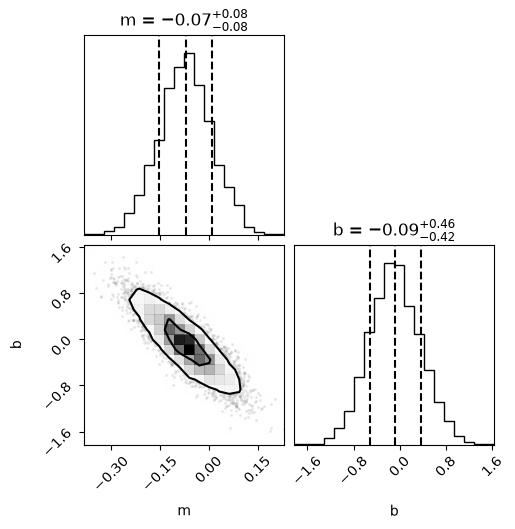

In [458]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)



In [459]:
#posterior predictive check for data2
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)


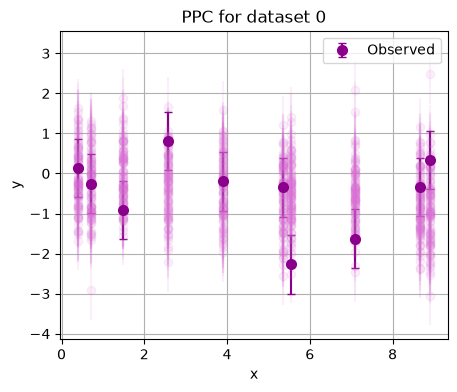

In [460]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id}')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.5806


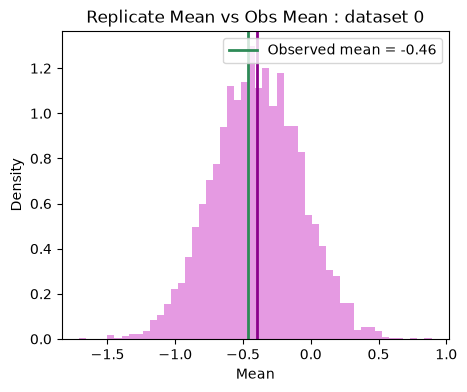

$\Delta$ mean = 0.07


In [461]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id}')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.2546


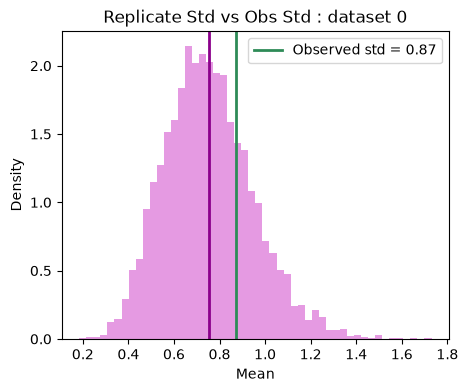

In [462]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id}')
ax.legend()

plt.show()


Dataset 3 Analysis

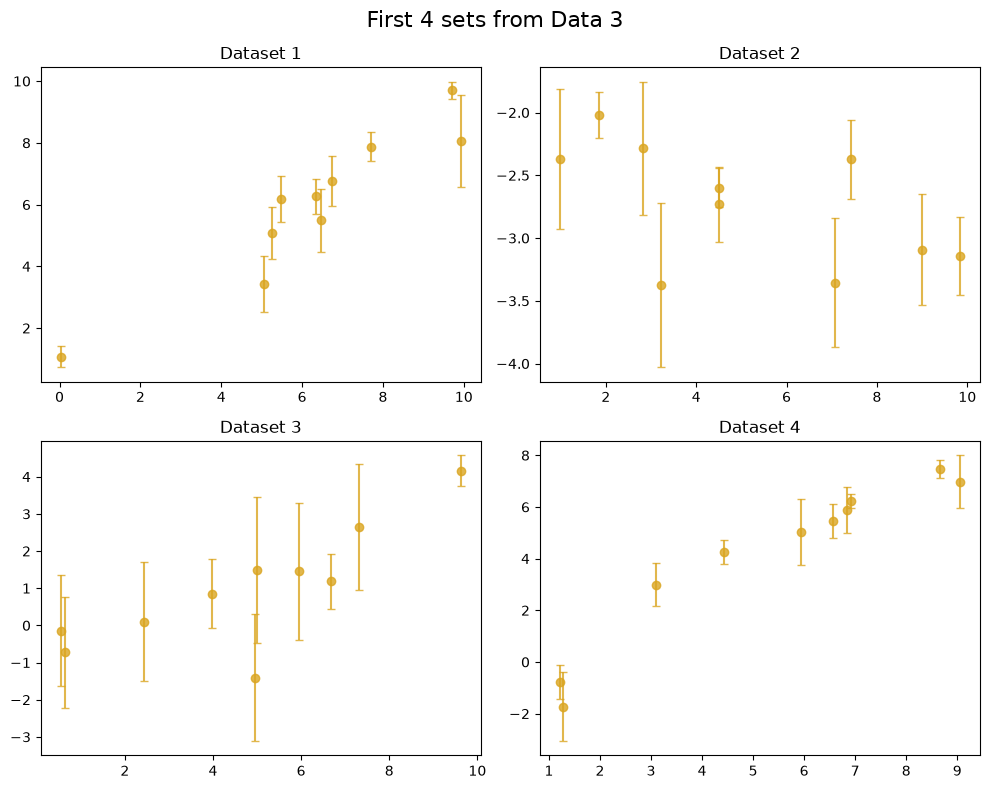

In [463]:
df = pd.read_csv('data3.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='goldenrod',
                ecolor='goldenrod', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 3', fontsize=16)    
plt.tight_layout()
plt.show()

a = 0.831741863756199, b = 0.7786789187407074
a = -0.08873758170742081, b = -2.279883113347441
a ranges from -3.067 to 2.161
b ranges from -7.046 to 7.129


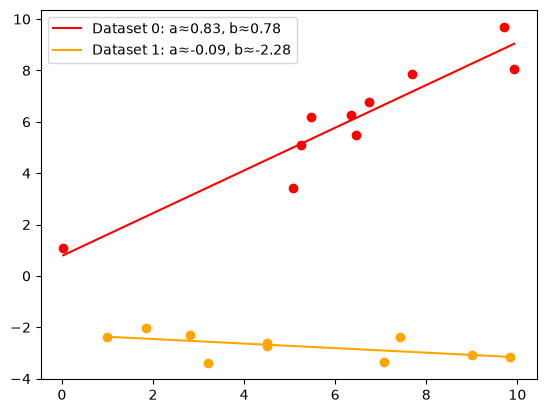

In [464]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')


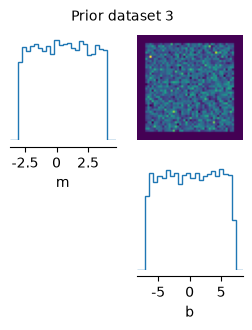

In [465]:
#Creating a prior for the set based on that range

prior_3 = BoxUniform(low=torch.tensor([-3, -7]), 
                      high=torch.tensor([4, 7]))

prior_samples3 = prior_3.sample((10000,))

fig, ax = pairplot(
    prior_samples3,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 3", fontsize = 10 )
plt.show()

In [466]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_3.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_3)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 138 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0  0.902481 0.062221  0.554064 0.416174
       1 -0.091621 0.044367 -2.165793 0.255079
       2  0.539949 0.104683 -1.331800 0.824630
       3  1.062802 0.088219 -1.388077 0.567053
       4 -0.636435 0.086945 -2.272121 0.430843
       5  0.454379 0.124397  3.765025 0.678811
       6  0.412451 0.207147  5.124420 1.179718
       7  0.716244 0.073962 -1.574168 0.336337
       8  2.082466 0.099799  3.301386 0.638447
       9  0.200403 0.166043 -0.804944 0.965872
      10 -0.761126 0.150635 -1.438201 1.132056
      11 -1.251842 0.126201 -0.448888 0.728677
      12 -0.836129 0.131789  3.034766 0.758024
      13  0.774051 0.122440  1.381258 0.797498
      14 -1.307329 0.060650  0.028653 0.362815
      15  1.173519 0.181825 -0.063591 0.991943
      16  0.690992 0.194616  0.416417 1.242229
      17 -1.320202 0.058105 -0.126519 0.246606
      18  0.045171 0.171387 -2.754616 0.890183
      19 -1.307387 0.050927 -2.638598 0.286880
      20 -0.4

  0%|          | 0/5000 [00:00<?, ?it/s]

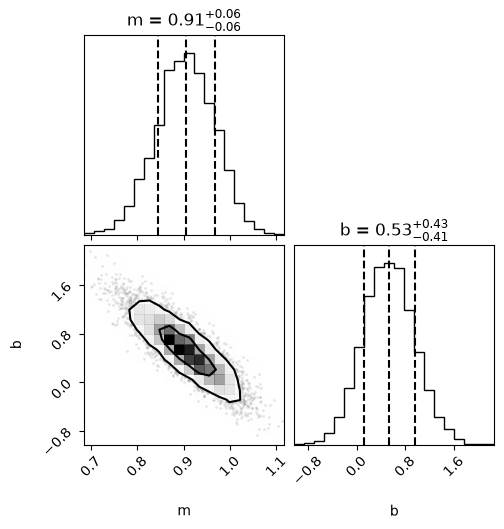

In [467]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

In [468]:
#data 3
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)


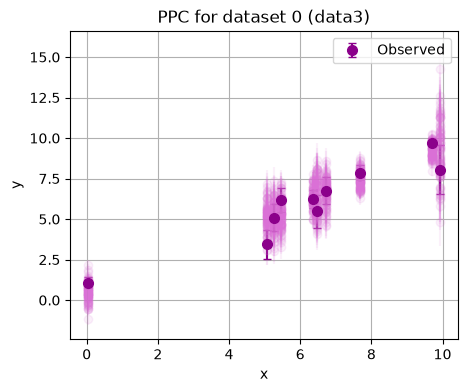

In [469]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id} (data3)')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.7268


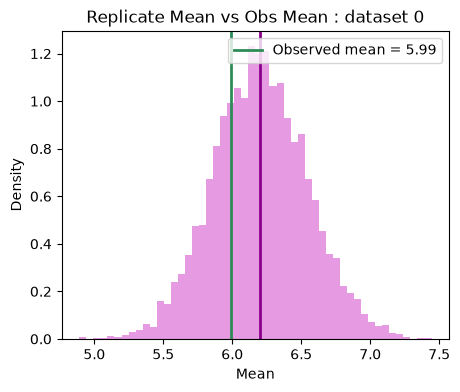

$\Delta$ mean = 0.21


In [470]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id}')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.717


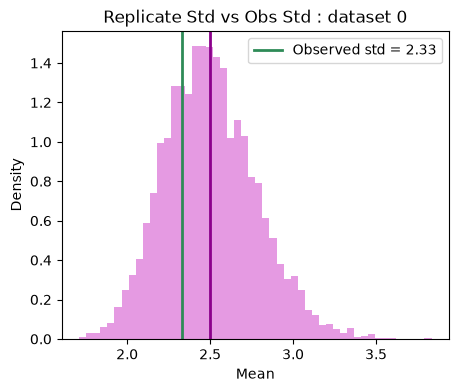

In [471]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id}')
ax.legend()

plt.show()


Dataset 4 Analysis

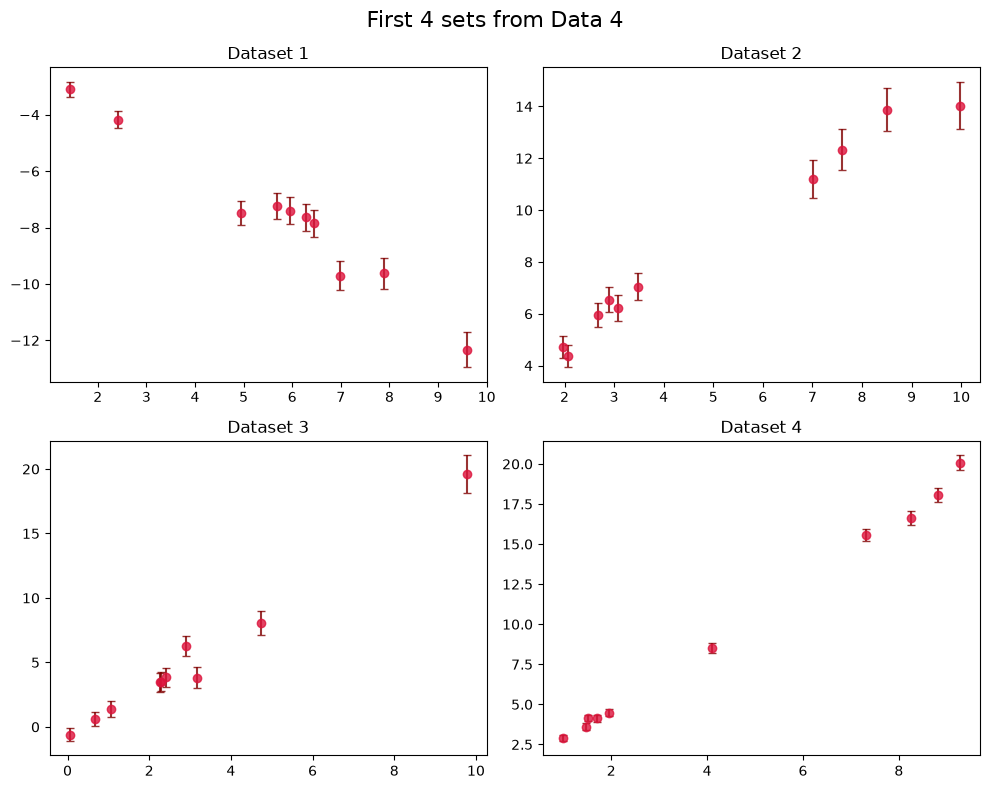

In [472]:
df = pd.read_csv('data4.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='crimson',
                ecolor='maroon', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 4', fontsize=16)    
plt.tight_layout()
plt.show()

a = -1.0785345154908206, b = -1.436439410083085
a = 1.2538404780466545, b = 2.4520852111998557
a ranges from -2.127 to 2.190
b ranges from -4.904 to 5.678


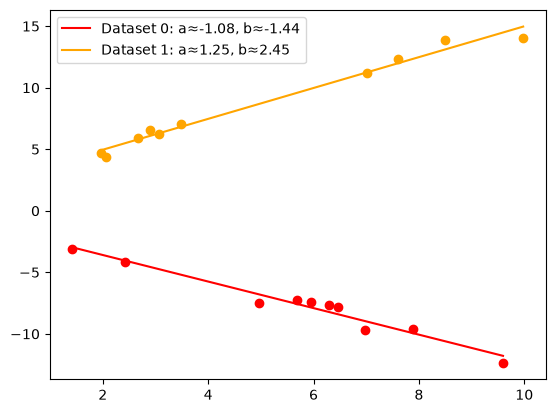

In [473]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []
#c_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)
    #c_fits.append(c_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit  , label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')
#print(f'c ranges from {min(c_fits):.3f} to {max(c_fits):.3f}')

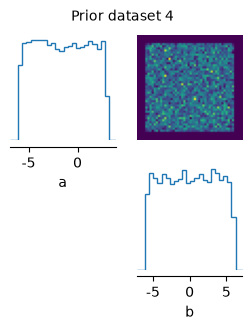

In [474]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_4 = BoxUniform(low=torch.tensor([-6, -6]), 
                      high=torch.tensor([3, 6]))

prior_samples4 = prior_4.sample((10000,))


fig, ax = pairplot(
    prior_samples4,
    labels=["a", "b", 'c'],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 4", fontsize = 10 )
plt.show()

In [475]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise

    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000  
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_4.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_4)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 131 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -1.048239 0.063269 -1.608323 0.297822
       1  1.325837 0.092416  2.082089 0.386534
       2  1.975219 0.129409 -0.694446 0.356048
       3  1.976498 0.088514  0.830529 0.222006
       4 -0.928539 0.067382 -3.512613 0.288849
       5  2.184163 0.168314  0.817332 0.536566
       6 -1.436221 0.093235 -3.899071 0.506514
       7 -0.720794 0.135672 -3.197454 0.642224
       8  0.904708 0.153748  3.682283 0.965106
       9 -1.800822 0.075138 -4.349093 0.483471
      10 -0.424180 0.109506  1.470709 0.522814
      11 -1.248226 0.098514 -2.551791 0.385286
      12  2.163973 0.108918  1.727545 0.601406
      13 -0.626960 0.078813 -0.582964 0.304064
      14 -0.609777 0.065931  0.345123 0.192234
      15 -0.583454 0.120037  4.360523 0.707800
      16  1.366458 0.083158 -3.137247 0.277970
      17 -0.401417 0.157021  2.833627 0.589304
      18  0.278986 0.104284  4.197807 0.459210
      19 -0.399986 0.163568  4.086622 0.651380
      20 -0.1

  0%|          | 0/5000 [00:00<?, ?it/s]

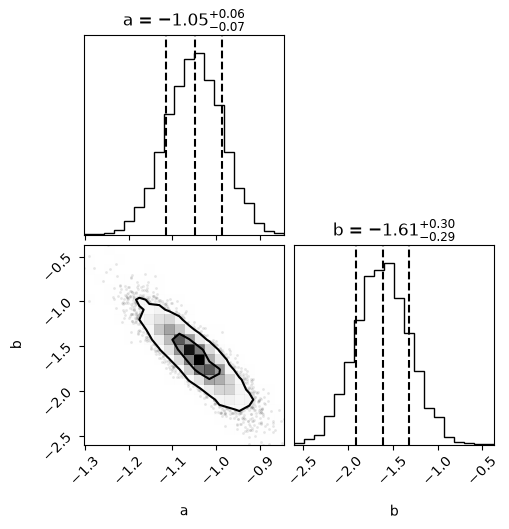

In [476]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

In [477]:
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)


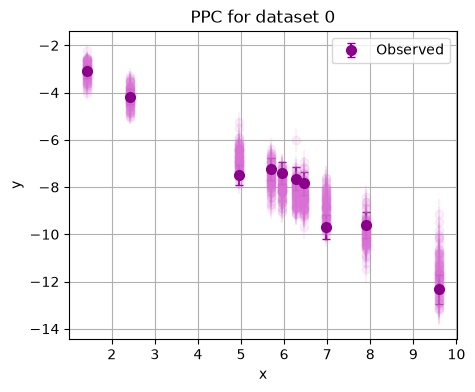

In [478]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id}')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.4898


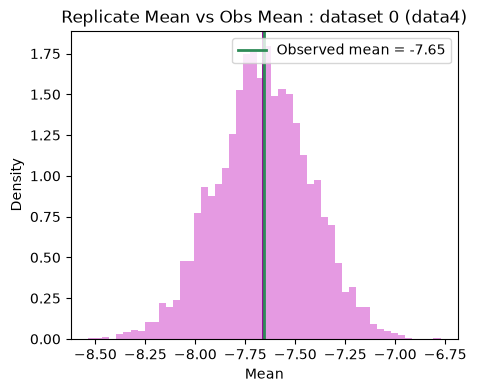

$\Delta$ mean = -0.01


In [479]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id} (data4)')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.3472


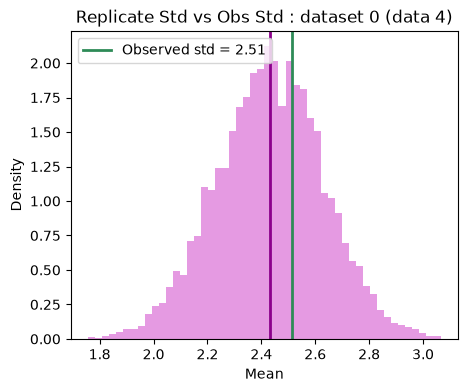

In [480]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id} (data 4)')
ax.legend()

plt.show()
